In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import SimpleITK as sitk
import numpy as np
import scipy.ndimage
import cv2
import os



In [38]:
# Charger un scan CT
def load_ct_scan1(scan_path):
    """Charge un scan médical .mhd et retourne un array NumPy"""
    image = sitk.ReadImage(scan_path)
    image_array = sitk.GetArrayFromImage(image)  # Convertir en numpy array
    return image, image_array

In [3]:

# Spécifier le chemin
annotations_path = "annotations.csv"
candidates_path = "candidates.csv"

# Charger les fichiers
annotations = pd.read_csv(annotations_path)
candidates = pd.read_csv(candidates_path)

# Afficher les premières lignes
#annotations.head()
# print(annotations.head())
candidates.head()



,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.08,-67.85,-311.92,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.21,-244.41,-245.17,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.66,-121.80,-286.62,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.66,-72.75,-308.41,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.25,-85.36,-362.51,0


In [49]:
annotations.head()


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


In [51]:
annotations.iloc[19]


seriesuid      1.3.6.1.4.1.14519.5.2.1.6279.6001.107351566259...
coordX                                                -46.783729
coordY                                                -66.973694
coordZ                                               -207.490896
diameter_mm                                             4.214452
Name: 19, dtype: object

In [7]:
print("Informations sur les annotations :")
print(annotations.info())

print("\nInformations sur les candidats :")
print(candidates.info())


Informations sur les annotations :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   seriesuid    1186 non-null   object 
 1   coordX       1186 non-null   float64
 2   coordY       1186 non-null   float64
 3   coordZ       1186 non-null   float64
 4   diameter_mm  1186 non-null   float64
dtypes: float64(4), object(1)
memory usage: 46.5+ KB
None

Informations sur les candidats :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551065 entries, 0 to 551064
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   seriesuid  551065 non-null  object 
 1   coordX     551065 non-null  float64
 2   coordY     551065 non-null  float64
 3   coordZ     551065 non-null  float64
 4   class      551065 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 21.0+ MB
None


In [9]:
#Statistique general
print(annotations.describe())
print(candidates.describe())


            coordX       coordY       coordZ  diameter_mm
count  1186.000000  1186.000000  1186.000000  1186.000000
mean     -5.067547     8.428113  -160.159029     8.306527
std      84.468115    98.316003   279.829437     4.762033
min    -164.351031  -283.834336  -790.074799     3.253443
25%     -80.909225   -51.549643  -221.197808     5.107177
50%     -32.855132    18.787926  -167.615160     6.433600
75%      76.830069    67.245915  -109.735281     9.696301
max     164.763985   271.405521  1790.494057    32.270030
              coordX         coordY         coordZ          class
count  551065.000000  551065.000000  551065.000000  551065.000000
mean       -2.005825       8.944721    -157.857852       0.002452
std        71.711619      89.428035     277.212320       0.049453
min      -201.113500    -317.330000    -895.220000       0.000000
25%       -62.126786     -35.780058    -224.790000       0.000000
50%       -17.271143      19.610000    -172.405402       0.000000
75%        61.87

In [11]:
print("Valeurs manquantes dans annotations :\n", annotations.isnull().sum())
print("\nValeurs manquantes dans candidates :\n", candidates.isnull().sum())


Valeurs manquantes dans annotations :
 seriesuid      0
coordX         0
coordY         0
coordZ         0
diameter_mm    0
dtype: int64

Valeurs manquantes dans candidates :
 seriesuid    0
coordX       0
coordY       0
coordZ       0
class        0
dtype: int64


In [15]:
nodule_counts = annotations['seriesuid'].value_counts()
#noduleserie= annotations['seriesuid'].value()
print("Nombre de nodules par scan :\n", nodule_counts)


Nombre de nodules par scan :
 seriesuid
1.3.6.1.4.1.14519.5.2.1.6279.6001.176030616406569931557298712518    12
1.3.6.1.4.1.14519.5.2.1.6279.6001.328789598898469177563438457842     9
1.3.6.1.4.1.14519.5.2.1.6279.6001.195557219224169985110295082004     9
1.3.6.1.4.1.14519.5.2.1.6279.6001.202187810895588720702176009630     9
1.3.6.1.4.1.14519.5.2.1.6279.6001.219428004988664846407984058588     9
                                                                    ..
1.3.6.1.4.1.14519.5.2.1.6279.6001.164988920331211858091402361989     1
1.3.6.1.4.1.14519.5.2.1.6279.6001.202464973819273687476049035824     1
1.3.6.1.4.1.14519.5.2.1.6279.6001.200841000324240313648595016964     1
1.3.6.1.4.1.14519.5.2.1.6279.6001.167919147233131417984739058859     1
1.3.6.1.4.1.14519.5.2.1.6279.6001.313605260055394498989743099991     1
Name: count, Length: 601, dtype: int64


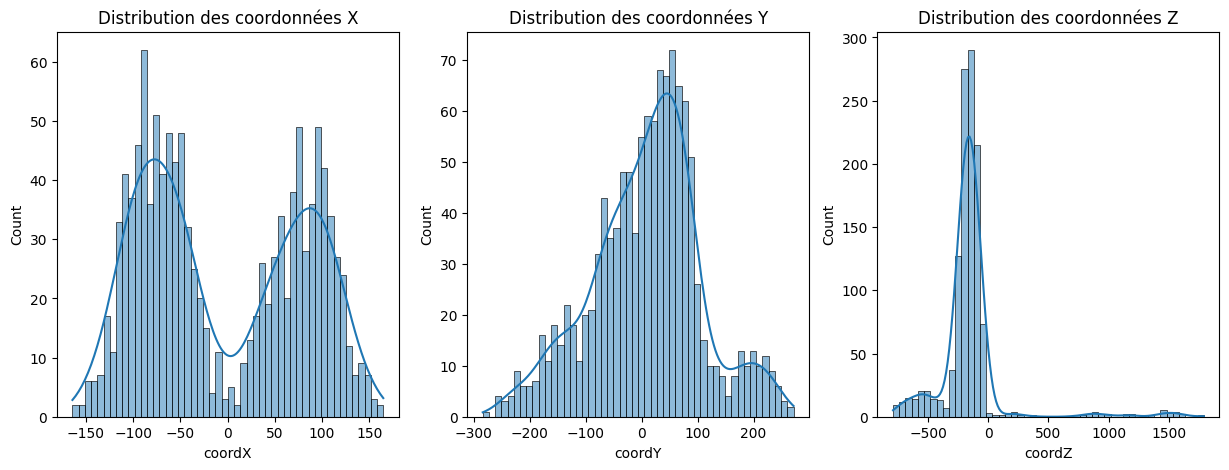

In [17]:
# On analyse la distribution des coordonnées X, Y et Z des nodules.
# permet de placer les coordonnée dans lespace 


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(annotations['coordX'], bins=50, kde=True)
plt.title("Distribution des coordonnées X")

plt.subplot(1,3,2)
sns.histplot(annotations['coordY'], bins=50, kde=True)
plt.title("Distribution des coordonnées Y")

plt.subplot(1,3,3)
sns.histplot(annotations['coordZ'], bins=50, kde=True)
plt.title("Distribution des coordonnées Z")

plt.show()


In [69]:
# Fonction pour rechercher une ligne par seriesuid
def find_annotation_by_seriesuid(seriesuid):
    result = annotations[annotations['seriesuid'] == seriesuid]
    if result.empty:
        print(f"Aucune annotation trouvée pour seriesuid: {seriesuid}")
    else:
        print(result)

# Exemple d'utilisation
seriesuid_to_search ="1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482151095585000946543"
find_annotation_by_seriesuid(seriesuid_to_search)

Aucune annotation trouvée pour seriesuid: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482151095585000946543


In [23]:
def world_to_voxel(coord, origin, spacing):
    """Convertit les coordonnées en millimètres du monde réel en indices voxel (pixels 3D)."""
    return [(coord[i] - origin[i]) / spacing[i] for i in range(len(coord))]


In [57]:
def position_scan(seriesuid):
    """Trouve la position d'un scan dans annotations.csv en fonction de son seriesuid."""
    for i, row in annotations.iterrows():  # Parcours chaque ligne du DataFrame
        if row["seriesuid"] == seriesuid:  # Vérifie si le seriesuid correspond
            return i  # Retourne l'index de la ligne trouvée
    return -1  # Retourne -1 si le seriesuid n'est pas trouvé


In [65]:
serie_id = "1.3.6.1.4.1.14519.5.2.1.6279.6001.100530488926682752765845212286"
index = position_scan(serie_id)

if index != -1:
    print(f"Scan trouvé à la ligne {index}")
else:
    print("Scan non trouvé dans annotations.csv")

Scan non trouvé dans annotations.csv


In [45]:
scan_file = "DatasetLuna/subset/1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482151095585000946543.mhd"
scan,scan_array = load_ct_scan(scan_file)
# Origine et espacement du scan
origin = scan.GetOrigin()
spacing = scan.GetSpacing()

# Conversion des coordonnées d'un nodule en pixels
x_voxel, y_voxel, z_voxel = world_to_voxel(
    [annotations.iloc[20]['coordX'], annotations.iloc[20]['coordY'], annotations.iloc[20]['coordZ']],
    origin, spacing
)

print(f"Coordonnées converties en pixels : X={x_voxel}, Y={y_voxel}, Z={z_voxel}")


Coordonnées converties en pixels : X=139.4047933189805, Y=133.92251629813774, Z=202.65341295999997


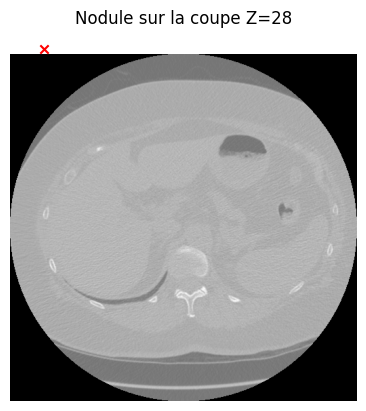

In [43]:
# Vérifier si Z est dans les limites du scan
z_voxel = int(z_voxel)
if 0 <= z_voxel < scan_array.shape[0]:  # Vérifie si Z est dans l’image
    plt.imshow(scan_array[z_voxel], cmap="gray")
    plt.scatter(x_voxel, y_voxel, c="red", marker="x")
    plt.axis('off')
    plt.title(f"Nodule sur la coupe Z={z_voxel}")
    plt.show()
else:
    print(f"⚠️ Erreur : L'index Z={z_voxel} est hors limites (0-{scan_array.shape[0]-1})")


In [35]:
# Visualisation d'un Scan et de ses Nodules


# # Charger un scan CT
# def load_ct_scan(scan_path):
#     image = sitk.ReadImage(scan_path)
#     image_array = sitk.GetArrayFromImage(image)  # Convertir en numpy array
#     return image_array

# # Spécifier un fichier .mhd
# scan_file = "DatasetLuna/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860.mhd"
# scan = load_ct_scan(scan_file)

# # Afficher une coupe du scan avec un nodule
# plt.imshow(scan[len(scan)//2], cmap="gray")
# plt.scatter(annotations.iloc[0][1], annotations.iloc[0][2], c="red", marker="x")
# plt.axis('off')
# plt.show()


# Vérification des colonnes du fichier annotations.csv
print(annotations.columns)

# Charger un scan CT
def load_ct_scan(scan_path):
    """Charge un scan médical .mhd et retourne un array NumPy"""
    image = sitk.ReadImage(scan_path)
    image_array = sitk.GetArrayFromImage(image)  # Convertir en numpy array
    return image_array

# Spécifier un fichier .mhd
scan_file = "DatasetLuna/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860.mhd"
scan = load_ct_scan(scan_file)

# Vérifier la structure des annotations pour trouver un nodule correspondant
nodule_info = annotations.iloc[0]  # Prend la première annotation

# Accéder aux coordonnées correctes
x_nodule = nodule_info['coordX']
y_nodule = nodule_info['coordY']
z_nodule = int(nodule_info['coordZ'])

# Vérifier que l'index Z est valide dans l'image
if 0 <= z_nodule < scan.shape[0]:
    plt.imshow(scan[z_nodule], cmap="gray")  # Afficher la tranche correspondant au nodule
    plt.scatter(x_nodule, y_nodule, c="red", marker="x")  # Marquer la position du nodule
    plt.axis('off')
    plt.title(f"Visualisation du nodule - Coupe Z: {z_nodule}")
    plt.show()
else:
    print(f"Erreur: L'index Z ({z_nodule}) est hors des limites de l'image (0-{scan.shape[0]-1}).")


Index(['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm'], dtype='object')
Erreur: L'index Z (-298) est hors des limites de l'image (0-193).


In [37]:
scan.shape

(194, 512, 512)

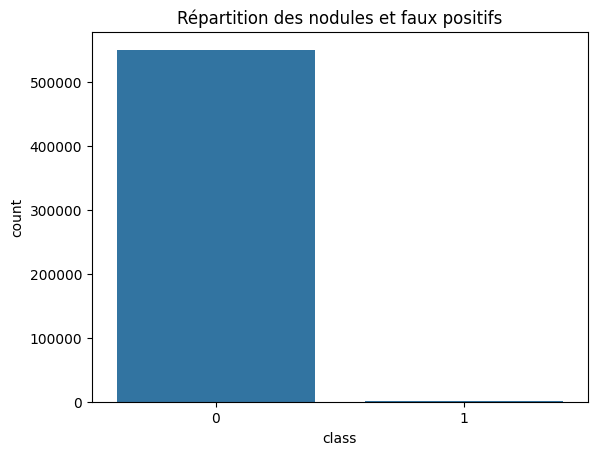

In [39]:
sns.countplot(x="class", data=candidates)
plt.title("Répartition des nodules et faux positifs")
plt.show()


In [ ]:
# pip install SimpleITK


In [ ]:
# pip install opencv-python


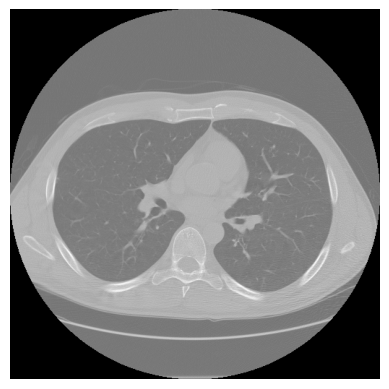

In [42]:


# # Charger un scan CT
# def load_ct_scan(scan_path):
#     image = sitk.ReadImage(scan_path)
#     image_array = sitk.GetArrayFromImage(image)  # Convertir en numpy array
#     return image_array

# # Spécifier un fichier .mhd
# scan_file = "DatasetLuna/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd"
# scan = load_ct_scan(scan_file)

# # Afficher une coupe axiale
# def show_scan_slice(scan, slice_idx):
#     plt.imshow(scan[slice_idx], cmap="gray")
#     plt.axis('off')
#     plt.show()

# # Afficher la coupe du milieu
# show_scan_slice(scan, len(scan) // 2)


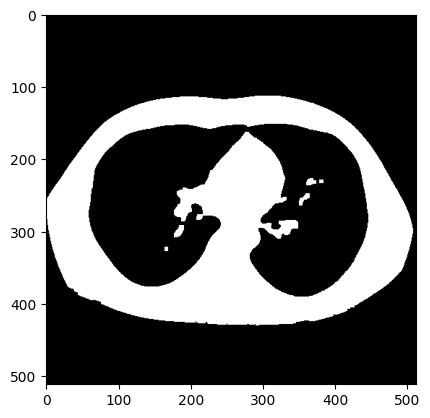

In [43]:


# def segment_lungs(image):
#     _, binary = cv2.threshold(image, -600, 255, cv2.THRESH_BINARY)  # Seuillage
#     kernel = np.ones((5,5), np.uint8)
#     binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)  # Nettoyage
#     return binary

# lung_mask = segment_lungs(scan[len(scan)//2])
# plt.imshow(lung_mask, cmap='gray')
# plt.show()


TypeError: Invalid shape (0, 32, 32) for image data

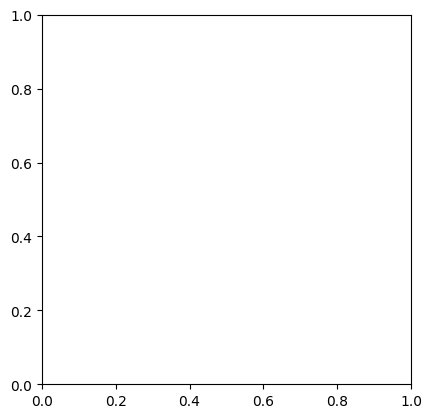

In [45]:
def extract_nodule_patch(scan, x, y, z, size=32):
    start_x, start_y, start_z = int(x-size//2), int(y-size//2), int(z-size//2)
    return scan[start_z:start_z+size, start_y:start_y+size, start_x:start_x+size]

nodule = extract_nodule_patch(scan, annotations.iloc[0]['coordX'], annotations.iloc[0]['coordY'], annotations.iloc[0]['coordZ'])
plt.imshow(nodule, cmap='gray')
plt.show()


#test ordonné************************************************************************************************************

CHARGEMENT DES DATAS


In [3]:
# 📂 Définir les chemins des fichiers
annotations_path = "annotations.csv"
candidates_path = "candidates.csv"

# 📌 Charger les fichiers CSV
annotations = pd.read_csv(annotations_path)
candidates = pd.read_csv(candidates_path)

In [10]:
# 📌 Afficher les 5 premières lignes des fichiers
print("🔍 Aperçu de annotations.csv :")
print(annotations.head())

print("\n🔍 Aperçu de candidates.csv :")
print(candidates.head())

🔍 Aperçu de annotations.csv :
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...  -24.013824  192.102405   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...    2.441547  172.464881   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  
3 -391.081276     8.143262  
4 -405.493732    18.545150  

🔍 Aperçu de candidates.csv :
                                           seriesuid  coordX  coordY  coordZ  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -56.08  -67.85 -311.92   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...   53.21 -244.41 -245.17   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.10022528

In [12]:
# 📌 Vérifier les informations sur les fichiers
print("\n📊 Informations sur annotations.csv :")
print(annotations.info())

print("\n📊 Informations sur candidates.csv :")
print(candidates.info())



📊 Informations sur annotations.csv :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   seriesuid    1186 non-null   object 
 1   coordX       1186 non-null   float64
 2   coordY       1186 non-null   float64
 3   coordZ       1186 non-null   float64
 4   diameter_mm  1186 non-null   float64
dtypes: float64(4), object(1)
memory usage: 46.5+ KB
None

📊 Informations sur candidates.csv :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551065 entries, 0 to 551064
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   seriesuid  551065 non-null  object 
 1   coordX     551065 non-null  float64
 2   coordY     551065 non-null  float64
 3   coordZ     551065 non-null  float64
 4   class      551065 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 21.0+ MB
None


In [14]:
# 📌 Vérifier les valeurs manquantes
print("\n❓ Valeurs manquantes dans annotations.csv :")
print(annotations.isnull().sum())

print("\n❓ Valeurs manquantes dans candidates.csv :")
print(candidates.isnull().sum())


❓ Valeurs manquantes dans annotations.csv :
seriesuid      0
coordX         0
coordY         0
coordZ         0
diameter_mm    0
dtype: int64

❓ Valeurs manquantes dans candidates.csv :
seriesuid    0
coordX       0
coordY       0
coordZ       0
class        0
dtype: int64


In [20]:
# 📊 Vérifier la distribution des nodules détectés
print("\n📊 Nombre de nodules par scan :")
print(annotations['seriesuid'].value_counts().head())

# 📌 Vérifier la distribution des classes (nodule = 1, faux positif = 0)
print("\n📊 Répartition des nodules et faux positifs dans candidates.csv :")
print(candidates["class"].value_counts())


📊 Nombre de nodules par scan :
seriesuid
1.3.6.1.4.1.14519.5.2.1.6279.6001.176030616406569931557298712518    12
1.3.6.1.4.1.14519.5.2.1.6279.6001.328789598898469177563438457842     9
1.3.6.1.4.1.14519.5.2.1.6279.6001.195557219224169985110295082004     9
1.3.6.1.4.1.14519.5.2.1.6279.6001.202187810895588720702176009630     9
1.3.6.1.4.1.14519.5.2.1.6279.6001.219428004988664846407984058588     9
Name: count, dtype: int64

📊 Répartition des nodules et faux positifs dans candidates.csv :
class
0    549714
1      1351
Name: count, dtype: int64


In [7]:
print(annotations.shape)

(1186, 5)


In [13]:
print(candidates.shape)

(551065, 5)


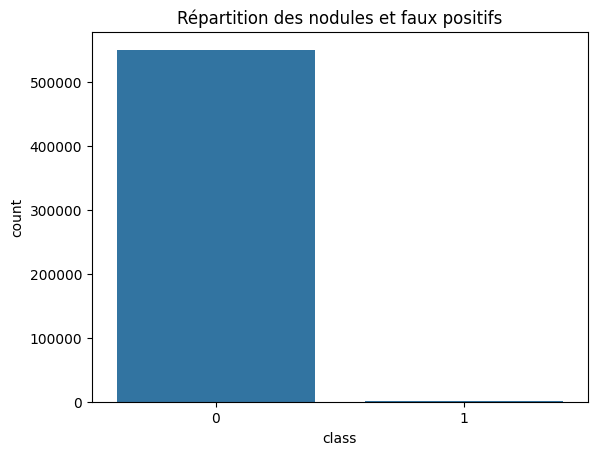

In [22]:
sns.countplot(x="class", data=candidates)
plt.title("Répartition des nodules et faux positifs")
plt.show()



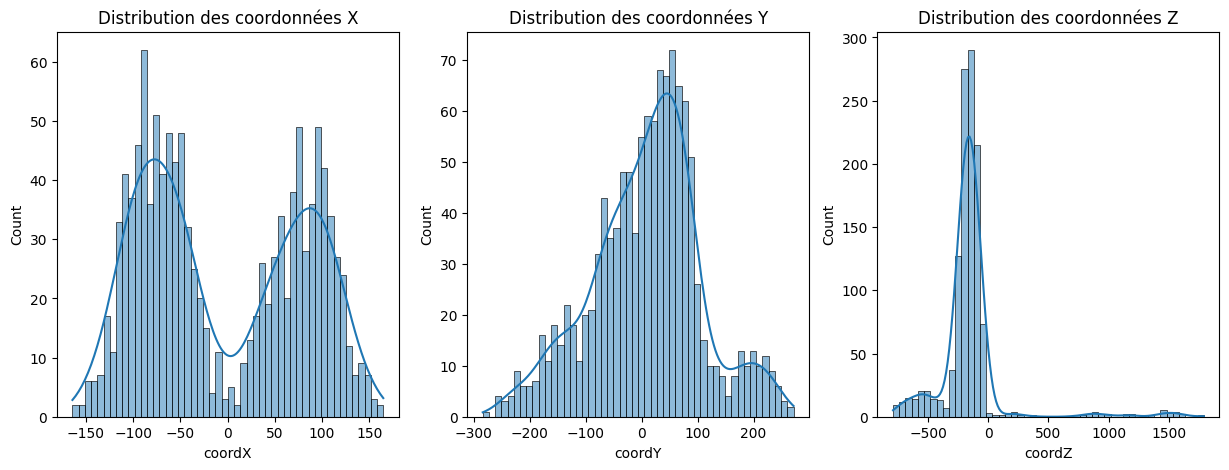

In [18]:
# 📊 Visualisation de la distribution des coordonnées des nodules


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(annotations['coordX'], bins=50, kde=True)
plt.title("Distribution des coordonnées X")

plt.subplot(1,3,2)
sns.histplot(annotations['coordY'], bins=50, kde=True)
plt.title("Distribution des coordonnées Y")

plt.subplot(1,3,3)
sns.histplot(annotations['coordZ'], bins=50, kde=True)
plt.title("Distribution des coordonnées Z")

plt.show()

In [24]:
# 📂 Définir le chemin des subsets
dataset_path = "DatasetLuna/"
subsets = [f for f in os.listdir(dataset_path) if f.startswith("subset")]

# 📊 Compter le nombre de scans par subset
scan_counts = {}

for subset in subsets:
    subset_path = os.path.join(dataset_path, subset)
    scan_files = [f for f in os.listdir(subset_path) if f.endswith(".mhd")]
    scan_counts[subset] = len(scan_files)

# 📌 Affichage des résultats
print("\n📊 Nombre total de scans par subset :")
for subset, count in scan_counts.items():
    print(f"{subset}: {count} scans")

# 📌 Nombre total de scans
total_scans = sum(scan_counts.values())
print(f"\n✅ Nombre total de scans dans LUNA16 : {total_scans}")



📊 Nombre total de scans par subset :
subset0: 89 scans
subset1: 89 scans
subset2: 89 scans
subset3: 89 scans
subset4: 89 scans
subset5: 89 scans
subset6: 89 scans
subset7: 89 scans
subset8: 88 scans
subset9: 88 scans

✅ Nombre total de scans dans LUNA16 : 888


In [26]:
#  Vérifier si chaque seriesuid de annotations.csv a un fichier MHD correspondant
missing_scans = []
for seriesuid in annotations["seriesuid"].unique():
    scan_file = os.path.join(dataset_path, f"subset*/{seriesuid}.mhd")
    if not os.path.exists(scan_file):
        missing_scans.append(seriesuid)

#  Résultats
if len(missing_scans) > 0:
    print(f"\n⚠️ {len(missing_scans)} scans manquants dans le dataset.")
else:
    print("\n✅ Toutes les annotations correspondent à un fichier de scan.")




⚠️ 601 scans manquants dans le dataset.


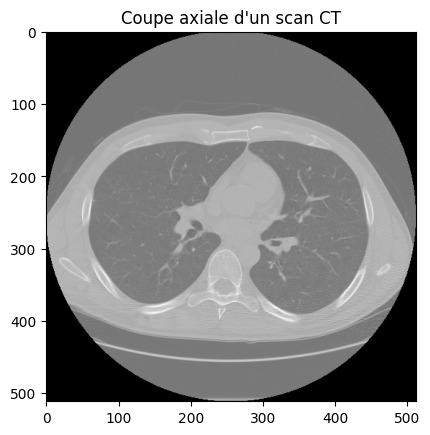

In [34]:
  #Charger un scan CT
def load_ct_scan(scan_path):
    """Charge un scan médical en format .mhd et retourne l'objet ITK et son array NumPy"""
    scan_itk = sitk.ReadImage(scan_path)  
    scan_array = sitk.GetArrayFromImage(scan_itk)  
    return scan_itk, scan_array  

#  Sélection d'un scan test
sample_scan_file = os.path.join(dataset_path, "subset0", "1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd")

#  Charger et afficher le scan
scan_itk, scan_array = load_ct_scan(sample_scan_file)

plt.imshow(scan_array[len(scan_array)//2], cmap="gray")
plt.title("Coupe axiale d'un scan CT")
plt.show()



In [50]:
#  Fonction pour charger un scan CT
def load_ct_scan(scan_path):
    """Charge un scan médical en format .mhd et retourne l'objet ITK et son array NumPy"""
    scan_itk = sitk.ReadImage(scan_path)  
    scan_array = sitk.GetArrayFromImage(scan_itk)  
    return scan_itk, scan_array  

# Conversion des coordonnées (mm → pixels)
def world_to_voxel(coord, origin, spacing):
    """Convertit les coordonnées en millimètres en indices voxel (pixels 3D)."""
    return [(coord[i] - origin[i]) / spacing[i] for i in range(len(coord))]

#  Normalisation des valeurs Hounsfield (HU)
def normalize_hu(image):
    """Normalise les valeurs Hounsfield entre 0 et 1"""
    MIN_HU, MAX_HU = -1000, 400  # Plage standard pour les poumons
    image = np.clip(image, MIN_HU, MAX_HU)  
    image = (image - MIN_HU) / (MAX_HU - MIN_HU)  
    return image

#  Segmentation des poumons
def segment_lungs(image):
    """Segmente les poumons en appliquant un seuillage et une suppression des petits objets."""
    _, binary = cv2.threshold(image, -600, 255, cv2.THRESH_BINARY)  
    kernel = np.ones((5,5), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)  
    return binary

# def segment_lungs(image):
#     _, binary = cv2.threshold(image, -600, 255, cv2.THRESH_BINARY)  # Seuillage
#     kernel = np.ones((5,5), np.uint8)
#     binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)  # Nettoyage
#     return binary

# lung_mask = segment_lungs(scan[len(scan)//2])
# plt.imshow(lung_mask, cmap='gray')
# plt.show()

#  Redimensionnement du scan

def resize_scan(image, new_shape=(128, 128, 128)):
    """Redimensionne un scan 3D (Z, Y, X) à la nouvelle forme souhaitée."""
    current_shape = image.shape  
    scale_factors = [new_shape[i] / current_shape[i] for i in range(3)]  
    resized_image = scipy.ndimage.zoom(image, scale_factors, order=1)  
    return resized_image


In [52]:
def display_raw_scan(scan_array):
    """Affiche la coupe centrale du scan brut (non traité)."""
    middle_slice = scan_array.shape[0] // 2  # Prendre une coupe centrale
    plt.figure(figsize=(5, 5))
    plt.imshow(scan_array[middle_slice], cmap="gray")
    plt.title("Scan brut - Coupe centrale")
    plt.axis("off")
    plt.show()

def display_normalized_scan(scan_array):
    """Affiche la coupe centrale du scan après normalisation HU."""
    middle_slice = scan_array.shape[0] // 2  
    plt.figure(figsize=(5, 5))
    plt.imshow(scan_array[middle_slice], cmap="gray")
    plt.title("Scan normalisé (HU)")
    plt.axis("off")
    plt.show()

def display_segmented_scan(segmented_scan):
    """Affiche la coupe centrale après segmentation des poumons."""
    middle_slice = segmented_scan.shape[0] // 2  
    plt.figure(figsize=(5, 5))
    plt.imshow(segmented_scan[middle_slice], cmap="gray")
    plt.title("Segmentation des poumons")
    plt.axis("off")
    plt.show()

def display_resized_scan(resized_scan):
    """Affiche la coupe centrale après redimensionnement."""
    middle_slice = resized_scan.shape[0] // 2  
    plt.figure(figsize=(5, 5))
    plt.imshow(resized_scan[middle_slice], cmap="gray")
    plt.title("Scan redimensionné")
    plt.axis("off")
    plt.show()



In [54]:
def display_scan_with_nodules(seriesuid):
    """Affiche un scan à chaque étape du prétraitement + nodules annotés."""

    #  Trouver le fichier MHD correspondant
    scan_path = None
    for subset in os.listdir(dataset_path):
        subset_path = os.path.join(dataset_path, subset)
        if os.path.isdir(subset_path):
            file_path = os.path.join(subset_path, f"{seriesuid}.mhd")
            if os.path.exists(file_path):
                scan_path = file_path
                break

    if scan_path is None:
        print(f"⚠️ Scan non trouvé pour seriesuid: {seriesuid}")
        return

    #  Chargement du scan
    scan_itk, scan_array = load_ct_scan(scan_path)
    
    #  Étape 1 : Affichage du scan brut
    display_raw_scan(scan_array)

    #  Récupérer les informations du scan
    origin = scan_itk.GetOrigin()
    spacing = scan_itk.GetSpacing()

    #  Normalisation des valeurs Hounsfield
    scan_array = normalize_hu(scan_array)
    
    #  Étape 2 : Affichage du scan normalisé
    display_normalized_scan(scan_array)

    #  Segmentation des poumons
    segmented_scan = np.array([segment_lungs(slice) for slice in scan_array])
    
    #  Étape 3 : Affichage du scan segmenté
    display_segmented_scan(segmented_scan)

    #  Redimensionnement du scan
    resized_scan = resize_scan(segmented_scan, (128, 128, 128))
    
    #  Étape 4 : Affichage du scan redimensionné
    display_resized_scan(resized_scan)

    #  Extraire les annotations correspondantes
    nodules = annotations[annotations["seriesuid"] == seriesuid]

    #  Étape 5 : Affichage du scan final avec nodules annotés
    plt.figure(figsize=(10, 5))
    middle_slice = resized_scan.shape[0] // 2  
    plt.imshow(resized_scan[middle_slice], cmap="gray")

    for _, nodule in nodules.iterrows():
        x_voxel, y_voxel, z_voxel = world_to_voxel([nodule["coordX"], nodule["coordY"], nodule["coordZ"]], origin, spacing)
        x_voxel, y_voxel, z_voxel = int(x_voxel), int(y_voxel), int(z_voxel)

        if z_voxel == middle_slice:  # Afficher uniquement les nodules visibles sur cette coupe
            plt.scatter(x_voxel, y_voxel, c="red", marker="x", s=100)

    plt.title(f"Nodules sur le scan {seriesuid}")
    plt.axis("off")
    plt.show()


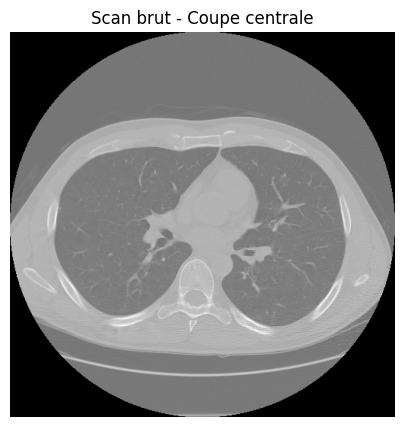

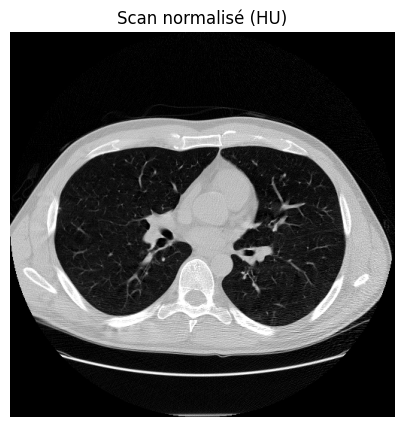

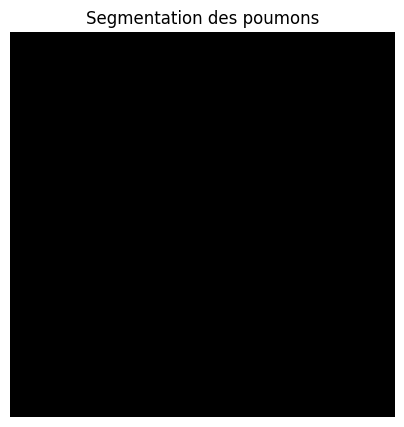

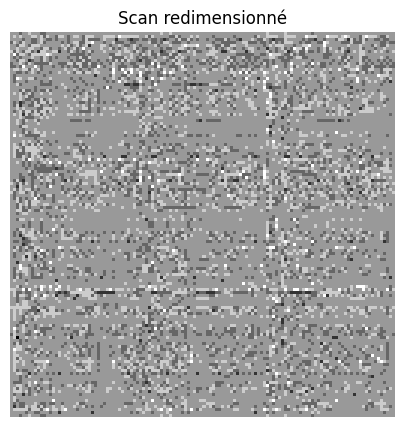

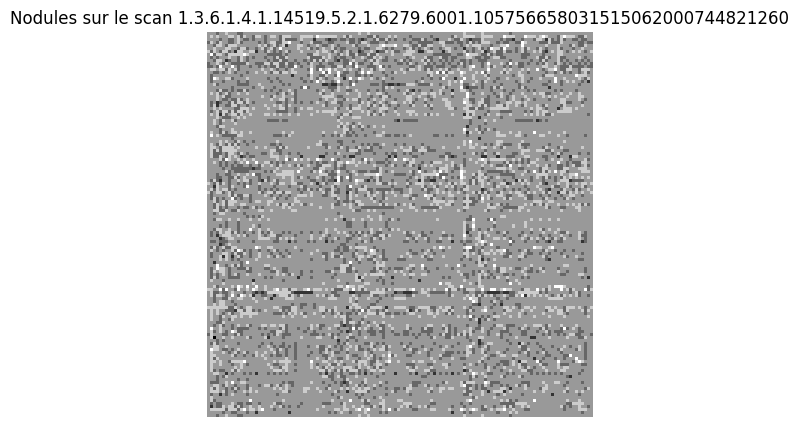

In [56]:
#  Tester avec un seriesuid spécifique
sample_seriesuid = "1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260"
display_scan_with_nodules(sample_seriesuid)